In [2]:
!pip install wfdb numpy scipy scikit-learn tensorflow matplotlib seaborn pandas


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import subprocess
import warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')

# Paths relative to ml/ (notebook location)
DB_PATH     = '../dataset/mit-bih-arrhythmia-database-1.0.0'
OUTPUTS_DIR = 'outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

MODEL_CHECKPOINT = f'{OUTPUTS_DIR}/tarang_best.keras'
TFLITE_PATH      = f'{OUTPUTS_DIR}/tarang_int8.tflite'
HEADER_PATH      = f'{OUTPUTS_DIR}/tarang_model.h'

print("TensorFlow version:", tf.__version__)
print("WFDB version:", wfdb.__version__)
print("All imports OK")
print(f"Dataset path: {DB_PATH}")
print(f"Outputs dir:  {OUTPUTS_DIR}/")


TensorFlow version: 2.20.0
WFDB version: 4.3.1
All imports OK
Dataset path: Dataset/mit-bih-arrhythmia-database-1.0.0
Outputs dir:  outputs/


In [4]:
# standard first record to explore
record = wfdb.rdrecord(f'{DB_PATH}/100')
annotation = wfdb.rdann(f'{DB_PATH}/100', 'atr')

print("=== RECORD INFO ===")
print(f"Signal names:     {record.sig_name}")
print(f"Sampling freq:    {record.fs} Hz")
print(f"Signal length:    {record.sig_len} samples")
print(f"Duration:         {record.sig_len / record.fs / 60:.1f} minutes")
print(f"Number of beats:  {len(annotation.sample)}")
print(f"\nFirst 20 annotation symbols: {annotation.symbol[:20]}")
print(f"Unique symbols in this record: {set(annotation.symbol)}")

=== RECORD INFO ===
Signal names:     ['MLII', 'V5']
Sampling freq:    360 Hz
Signal length:    650000 samples
Duration:         30.1 minutes
Number of beats:  2274

First 20 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
Unique symbols in this record: {'+', 'N', 'V', 'A'}


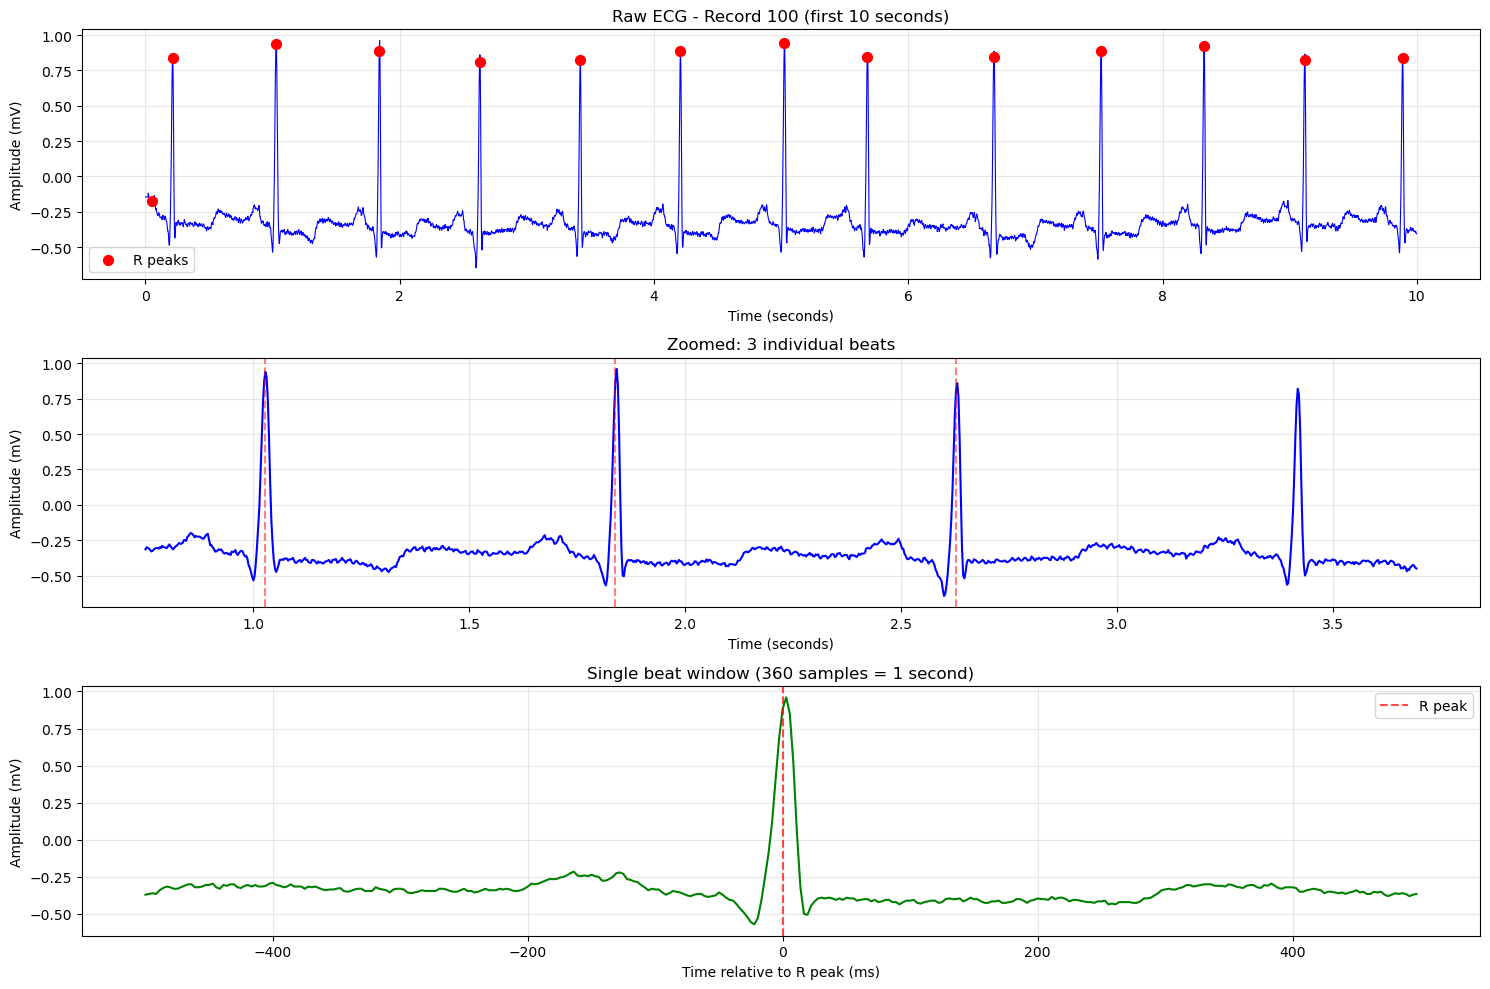

In [25]:
signal = record.p_signal[:, 0]
fs = record.fs

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

start, end = 0, 10 * fs
t = np.arange(start, end) / fs

axes[0].plot(t, signal[start:end], 'b-', linewidth=0.8)
axes[0].set_title('Raw ECG - Record 100 (first 10 seconds)', fontsize=12)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

r_peaks_in_window = [p for p in annotation.sample if start <= p < end]
axes[0].scatter(
    [p/fs for p in r_peaks_in_window],
    [signal[p] for p in r_peaks_in_window],
    color='red', s=50, zorder=5, label='R peaks'
)
axes[0].legend()

beat_start = r_peaks_in_window[2] - 100
beat_end   = r_peaks_in_window[5] + 100
t2 = np.arange(beat_start, beat_end) / fs

axes[1].plot(t2, signal[beat_start:beat_end], 'b-', linewidth=1.5)
axes[1].set_title('Zoomed: 3 individual beats', fontsize=12)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, alpha=0.3)

for p in r_peaks_in_window[2:5]:
    axes[1].axvline(x=p/fs, color='red', alpha=0.5, linestyle='--')

center = r_peaks_in_window[3]
single_beat = signal[center-180 : center+180]
axes[2].plot(np.arange(-180, 180)/fs*1000, single_beat, 'g-', linewidth=1.5)
axes[2].axvline(x=0, color='red', alpha=0.7, linestyle='--', label='R peak')
axes[2].set_title('Single beat window (360 samples = 1 second)', fontsize=12)
axes[2].set_xlabel('Time relative to R peak (ms)')
axes[2].set_ylabel('Amplitude (mV)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/ecg_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# AAMI/ANSI EC57 beat mapping - do not modify; this is the clinical standard
BEAT_MAP = {
    # Normal
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # Supraventricular ectopic
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # Ventricular ectopic (PVC - the dangerous one)
    'V': 'V', 'E': 'V',
    # Fusion
    'F': 'F',
    # Unknown/paced - excluded from training
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}

# All 48 MIT-BIH records
ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

print("Scanning all 48 records for class distribution...\n")

all_symbols = []
record_stats = []

for rec_num in ALL_RECORDS:
    try:
        ann = wfdb.rdann(f'{DB_PATH}/{rec_num}', 'atr')
        mapped = [BEAT_MAP.get(s, None) for s in ann.symbol]
        mapped = [m for m in mapped if m is not None]
        all_symbols.extend(mapped)

        counts = Counter(mapped)
        record_stats.append({
            'record': rec_num,
            'total':  len(mapped),
            'N':      counts.get('N', 0),
            'S':      counts.get('S', 0),
            'V':      counts.get('V', 0),
            'F':      counts.get('F', 0),
            'Q':      counts.get('Q', 0),
        })
        print(f"  Record {rec_num}: {len(mapped)} beats - {dict(counts)}")

    except Exception as ex:
        print(f"  Record {rec_num}: FAILED - {ex}")

print("\n" + "="*50)
print("FULL DATASET CLASS DISTRIBUTION")
print("="*50)
total_counter = Counter(all_symbols)
total = sum(total_counter.values())

for cls, count in sorted(total_counter.items()):
    pct = count / total * 100
    bar = '#' * int(pct / 2)
    print(f"  {cls}: {count:6d} beats ({pct:5.1f}%) {bar}")

print(f"\nTotal beats: {total:,}")

Scanning all 48 records for class distribution...

  Record 100: 2273 beats - {'N': 2239, 'S': 33, 'V': 1}
  Record 101: 1865 beats - {'N': 1860, 'Q': 2, 'S': 3}
  Record 102: 2187 beats - {'Q': 2084, 'N': 99, 'V': 4}
  Record 103: 2084 beats - {'N': 2082, 'S': 2}
  Record 104: 2229 beats - {'Q': 2064, 'N': 163, 'V': 2}
  Record 105: 2572 beats - {'N': 2526, 'V': 41, 'Q': 5}
  Record 106: 2027 beats - {'N': 1507, 'V': 520}
  Record 107: 2137 beats - {'Q': 2078, 'V': 59}
  Record 108: 1763 beats - {'N': 1740, 'V': 17, 'F': 2, 'S': 4}
  Record 109: 2532 beats - {'N': 2492, 'F': 2, 'V': 38}
  Record 111: 2124 beats - {'N': 2123, 'V': 1}
  Record 112: 2539 beats - {'N': 2537, 'S': 2}
  Record 113: 1795 beats - {'N': 1789, 'S': 6}
  Record 114: 1879 beats - {'N': 1820, 'V': 43, 'S': 12, 'F': 4}
  Record 115: 1953 beats - {'N': 1953}
  Record 116: 2412 beats - {'N': 2302, 'V': 109, 'S': 1}
  Record 117: 1535 beats - {'N': 1534, 'S': 1}
  Record 118: 2278 beats - {'N': 2166, 'V': 16, 'S': 96}

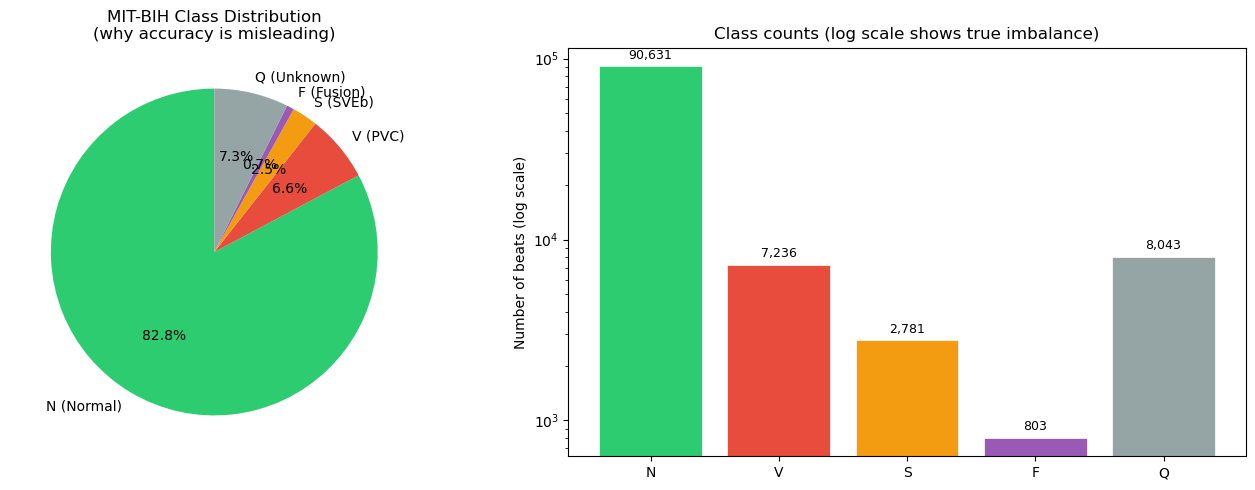

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = ['N (Normal)', 'V (PVC)', 'S (SVEb)', 'F (Fusion)', 'Q (Unknown)']
counts  = [total_counter.get(c[0], 0) for c in classes]
colors  = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']

axes[0].pie(counts, labels=classes, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('MIT-BIH Class Distribution\n(why accuracy is misleading)', fontsize=12)

axes[1].bar(range(len(classes)), counts, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_yscale('log')
axes[1].set_xticks(range(len(classes)))
axes[1].set_xticklabels([c.split(' ')[0] for c in classes])
axes[1].set_ylabel('Number of beats (log scale)')
axes[1].set_title('Class counts (log scale shows true imbalance)', fontsize=12)
for i, (c, count) in enumerate(zip(classes, counts)):
    axes[1].text(i, count * 1.1, f'{count:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# NLMS FILTER HOOK
# When nlms_filter.py is ready, in the beat segmentation cell replace:
#   signal = record.p_signal[:, 0]
# with:
#   signal = nlms_filter(record.p_signal[:, 0], imu_signal)
# Everything after that line stays identical.
# Suggested starting params: filter_order=32, step_size=0.01

In [6]:
WINDOW = 180        # samples before/after R peak -> 360 total = 1 second at 360Hz
                    # Equal context before (P wave) and after (T wave)

CLASSES_TO_USE = ['N', 'V', 'S']
# Excluding F (fusion - ambiguous) and Q (paced - not clinically relevant)

all_beats        = []
all_labels       = []
all_records_used = []

print("Loading and segmenting beats...")
print(f"Window: {WINDOW*2} samples ({WINDOW*2/360*1000:.0f}ms) centered on R peak\n")

for rec_num in ALL_RECORDS:
    try:
        record     = wfdb.rdrecord(f'{DB_PATH}/{rec_num}')
        annotation = wfdb.rdann(f'{DB_PATH}/{rec_num}', 'atr')

        signal = record.p_signal[:, 0]  # channel 0 only

        # Normalize per record - different records have different amplitudes due to
        # electrode placement, skin resistance, and equipment differences.
        # Z-score normalization so the model learns shape, not amplitude.
        mean = np.mean(signal)
        std  = np.std(signal)
        if std < 1e-8:
            print(f"  Record {rec_num}: near-zero std, skipping")
            continue
        signal = (signal - mean) / std

        beats_this_record = 0

        for peak, sym in zip(annotation.sample, annotation.symbol):
            mapped = BEAT_MAP.get(sym, None)
            if mapped not in CLASSES_TO_USE:
                continue
            if peak - WINDOW < 0 or peak + WINDOW >= len(signal):
                continue

            beat = signal[peak - WINDOW : peak + WINDOW]

            if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                continue

            all_beats.append(beat)
            all_labels.append(mapped)
            all_records_used.append(rec_num)
            beats_this_record += 1

        print(f"  Record {rec_num}: {beats_this_record} beats loaded")

    except Exception as ex:
        print(f"  Record {rec_num}: FAILED - {ex}")

# shape: (N, 360, 1) - CNNs expect (samples, timesteps, channels)
X = np.array(all_beats, dtype=np.float32)[..., np.newaxis]
y_raw        = np.array(all_labels)
records_used = np.array(all_records_used)

print(f"\n{'='*50}")
print(f"DATASET SUMMARY")
print(f"{'='*50}")
print(f"X shape:  {X.shape}  <- (beats, timesteps, channels)")
print(f"y shape:  {y_raw.shape}")
print(f"Classes:  {Counter(y_raw)}")
print(f"Memory:   {X.nbytes / 1024 / 1024:.1f} MB")

Loading and segmenting beats...
Window: 360 samples (1000ms) centered on R peak

  Record 100: 2271 beats loaded
  Record 101: 1862 beats loaded
  Record 102: 103 beats loaded
  Record 103: 2083 beats loaded
  Record 104: 165 beats loaded
  Record 105: 2567 beats loaded
  Record 106: 2027 beats loaded
  Record 107: 59 beats loaded
  Record 108: 1760 beats loaded
  Record 109: 2528 beats loaded
  Record 111: 2124 beats loaded
  Record 112: 2537 beats loaded
  Record 113: 1793 beats loaded
  Record 114: 1875 beats loaded
  Record 115: 1951 beats loaded
  Record 116: 2411 beats loaded
  Record 117: 1534 beats loaded
  Record 118: 2277 beats loaded
  Record 119: 1987 beats loaded
  Record 121: 1861 beats loaded
  Record 122: 2474 beats loaded
  Record 123: 1517 beats loaded
  Record 124: 1613 beats loaded
  Record 200: 2598 beats loaded
  Record 201: 1960 beats loaded
  Record 202: 2134 beats loaded
  Record 203: 2974 beats loaded
  Record 205: 2644 beats loaded
  Record 207: 1859 beats lo

In [13]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# Patient-wise split — separate patients in every set, no overlap.
TEST_RECORDS  = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119,
                 201, 202, 203, 205, 207, 208, 209, 210, 217, 219,
                 221, 223, 228, 231, 233, 234]
TRAIN_RECORDS = [r for r in ALL_RECORDS if r not in TEST_RECORDS]

# Fixed val records — chosen to give val both V and S coverage
# while keeping the S-dominant records (232: 1382S, 222: 209S) in TRAINING.
# Val: 105 (41V), 124 (47V+31S), 214 (256V), 220 (94S)
VAL_RECORDS          = [105, 124, 214, 220]
ACTUAL_TRAIN_RECORDS = [r for r in TRAIN_RECORDS if r not in VAL_RECORDS]

print(f"\nTrain patients ({len(ACTUAL_TRAIN_RECORDS)}): {ACTUAL_TRAIN_RECORDS}")
print(f"Val   patients ({len(VAL_RECORDS)}): {VAL_RECORDS}")
print(f"Test  patients ({len(TEST_RECORDS)}): {len(TEST_RECORDS)} records")

train_mask = np.isin(records_used, ACTUAL_TRAIN_RECORDS)
val_mask   = np.isin(records_used, VAL_RECORDS)
test_mask  = np.isin(records_used, TEST_RECORDS)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTrain: {len(X_train):,}  -- {Counter(le.inverse_transform(y_train))}")
print(f"Val:   {len(X_val):,}   -- {Counter(le.inverse_transform(y_val))}")
print(f"Test:  {len(X_test):,}  -- {Counter(le.inverse_transform(y_test))}")


Label encoding:
  0 = N
  1 = S
  2 = V

Train patients (18): [100, 102, 103, 104, 107, 111, 113, 117, 121, 122, 123, 200, 212, 213, 215, 222, 230, 232]
Val   patients (4): [105, 124, 214, 220]
Test  patients (26): 26 records

Train: 34,092  -- Counter({np.str_('N'): 31115, np.str_('S'): 1695, np.str_('V'): 1282})
Val:   8,483   -- Counter({np.str_('N'): 8014, np.str_('V'): 344, np.str_('S'): 125})
Test:  58,023  -- Counter({np.str_('N'): 51453, np.str_('V'): 5609, np.str_('S'): 961})


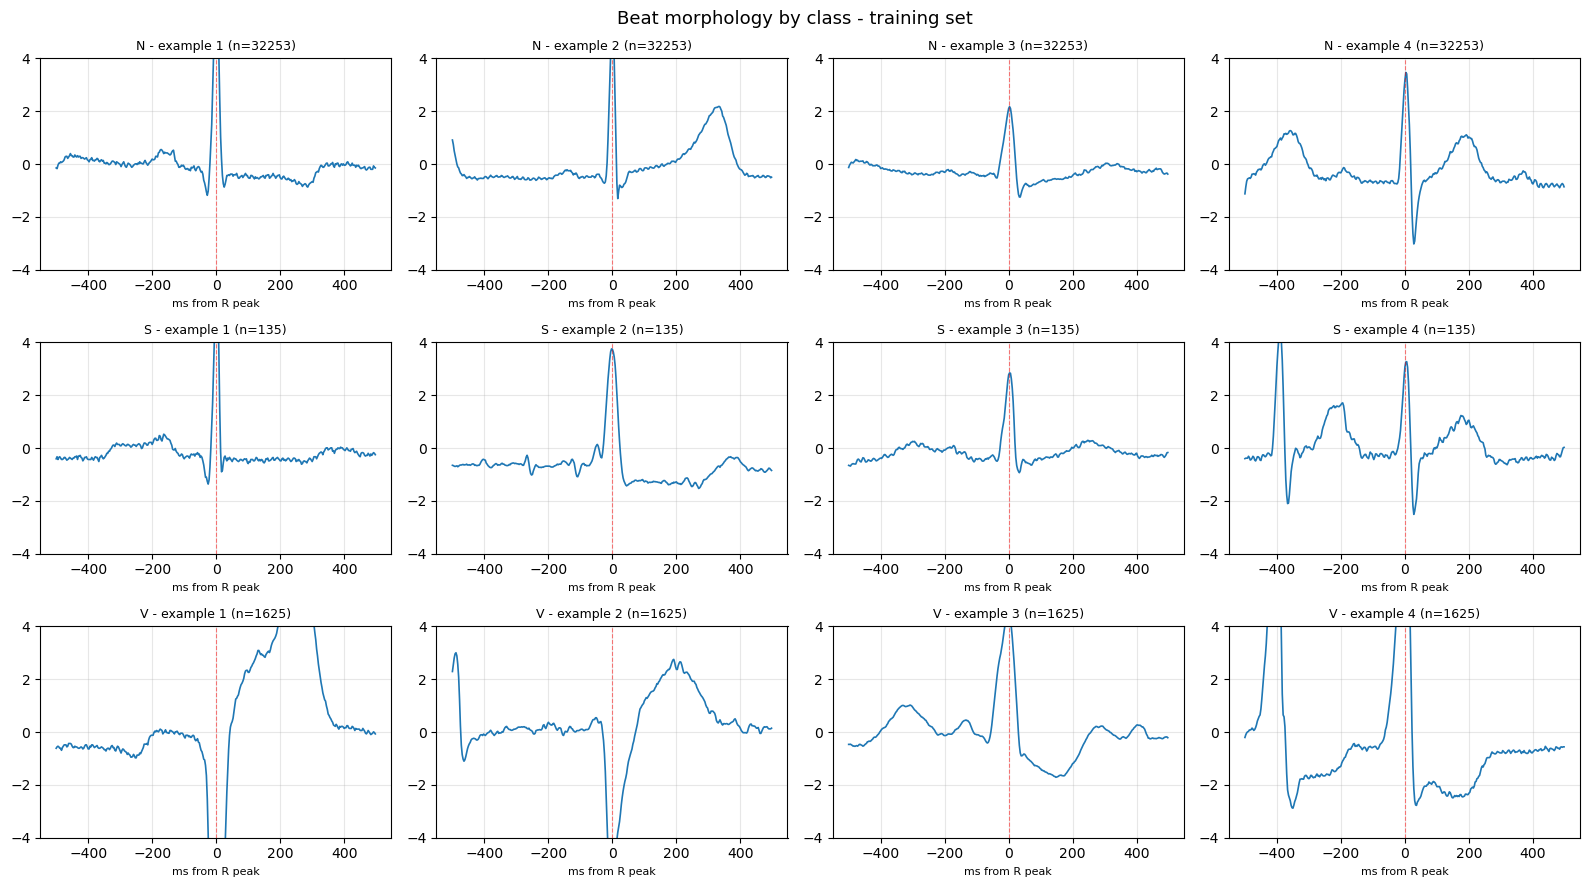

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
t = np.arange(-WINDOW, WINDOW) / 360 * 1000

for class_idx, class_name in enumerate(le.classes_):
    class_mask  = y_train == class_idx
    class_beats = X_train[class_mask]

    n_beats = len(class_beats)
    step = max(1, (n_beats - 1) // 3)  # spread 4 examples evenly across available beats

    for example_idx in range(4):
        ax   = axes[class_idx][example_idx]
        beat_idx = min(example_idx * step, n_beats - 1)
        beat = class_beats[beat_idx][:, 0]
        ax.plot(t, beat, linewidth=1.2)
        ax.axvline(x=0, color='red', alpha=0.5, linestyle='--', linewidth=0.8)
        ax.set_title(f'{class_name} - example {example_idx+1} (n={n_beats})', fontsize=9)
        ax.set_xlabel('ms from R peak', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-4, 4)

plt.suptitle('Beat morphology by class - training set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/beat_morphology.png', dpi=150, bbox_inches='tight')
plt.show()

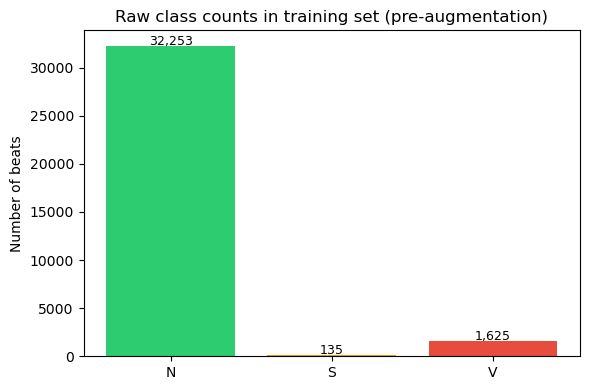

In [32]:
classes_list = [le.classes_[i] for i in range(len(le.classes_))]
counts_list  = [np.sum(y_train == i) for i in range(len(le.classes_))]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(classes_list, counts_list, color=colors)
ax.set_title('Raw class counts in training set (pre-augmentation)')
ax.set_ylabel('Number of beats')
for i, v in enumerate(counts_list):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
def augment_class_batch(X_c, class_name, n_copies):
    """
    Vectorized augmentation for a single class.
    X_c:      shape (n, 360, 1)
    Returns:  shape (n * n_copies, 360, 1) — all copies batched together
    """
    n = len(X_c)
    all_aug = []

    for _ in range(n_copies):
        a = X_c[:, :, 0].copy()          # (n, 360)

        # 1. Amplitude scaling ±15%
        a *= np.random.uniform(0.85, 1.15, (n, 1))

        # 2. Baseline wander  (0.3–0.8 Hz, realistic range)
        t      = np.linspace(0, 2 * np.pi, 360)
        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.15, n)
        wander = amps[:, None] * np.sin(freqs[:, None] * t[None, :])
        a     += wander

        # 3. Gaussian noise (electrode noise)
        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape)

        # 4. Time shift ±5 samples MAX — keeps R peak aligned
        shifts = np.random.randint(-5, 6, n)
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i])

        # 5. S only: P wave amplitude perturbation (first 80 samples)
        if class_name == 'S':
            a[:, :80] *= np.random.uniform(0.5, 1.5, (n, 1))

        all_aug.append(a[:, :, np.newaxis].astype(np.float32))  # (n, 360, 1)

    return np.concatenate(all_aug, axis=0)   # (n * n_copies, 360, 1)


# N: 0 extra copies (dominates)
# V: 3 extra copies -> 4x total
# S: 8 extra copies -> 9x total
AUG_COPIES = {'N': 0, 'V': 3, 'S': 8}

print("Augmenting minority classes (vectorized)...")
X_aug_list = [X_train]
y_aug_list = [y_train]

for class_idx, class_name in enumerate(le.classes_):
    n_copies = AUG_COPIES.get(class_name, 0)
    if n_copies == 0:
        continue
    mask = y_train == class_idx
    X_c  = X_train[mask]
    y_c  = y_train[mask]
    X_aug_list.append(augment_class_batch(X_c, class_name, n_copies))
    y_aug_list.append(np.tile(y_c, n_copies))   # repeat labels n_copies times

X_train_aug = np.concatenate(X_aug_list, axis=0)
y_train_aug = np.concatenate(y_aug_list, axis=0)

idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[idx]
y_train_aug = y_train_aug[idx]

print(f"Before aug: {Counter(le.inverse_transform(y_train))}")
print(f"After aug:  {Counter(le.inverse_transform(y_train_aug))}")
print(f"Total training beats: {len(X_train_aug):,}")


Augmenting minority classes (vectorized)...
Before aug: Counter({np.str_('N'): 31115, np.str_('S'): 1695, np.str_('V'): 1282})
After aug:  Counter({np.str_('N'): 31115, np.str_('S'): 15255, np.str_('V'): 5128})
Total training beats: 51,498


In [15]:
def build_tarang_cnn_v2(input_shape=(360, 1), num_classes=3):
    inputs = tf.keras.Input(shape=input_shape, name='ecg_input')

    # Block 1 — local waveform features
    x = tf.keras.layers.Conv1D(32, 7, padding='same', use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 2 — QRS morphology
    x = tf.keras.layers.Conv1D(64, 5, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 3 — T wave / ST segment
    x = tf.keras.layers.Conv1D(128, 5, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 4 — extra capacity for S class discrimination
    x = tf.keras.layers.Conv1D(128, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax',
                                     name='predictions')(x)
    return tf.keras.Model(inputs, outputs, name='Tarang_ECG_v2')


model = build_tarang_cnn_v2(num_classes=len(le.classes_))
model.summary()

total_params = model.count_params()
print(f"\nParameters: {total_params:,}")
print(f"Est. Int8:  ~{total_params/1024:.1f} KB  "
      f"({'PASS' if total_params < 51200 else 'OVER 50KB — will need pruning for EFR32'})")


Model: "Tarang_ECG_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)               │ (None, 360, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 360, 32)             │             224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 360, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 360, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 180, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_3                  │ (None, 180, 32)             │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 180, 64)             │          10,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 180, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 180, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 90, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_4                  │ (None, 90, 64)              │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 90, 128)             │          40,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 90, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 90, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_5                  │ (None, 90, 128)             │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 90, 128)             │          49,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 90, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 90, 128)             │              

 Total params: 110,627 (432.14 KB)

 Trainable params: 109,795 (428.89 KB)

 Non-trainable params: 832 (3.25 KB)


Parameters: 110,627
Est. Int8:  ~108.0 KB  (OVER 50KB — will need pruning for EFR32)


In [16]:
# Class weights: balanced baseline, then S doubled for extra push
cw = compute_class_weight('balanced', classes=np.unique(y_train_aug), y=y_train_aug)
cw_dict = dict(enumerate(cw))

s_idx = int(np.where(le.classes_ == 'S')[0])
cw_dict[s_idx] *= 2.0   # double the balanced weight for S

print("Class weights:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {cw_dict[i]:.3f}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_CHECKPOINT, monitor='val_loss',
        save_best_only=True, verbose=0
    ),
]

print(f"\nTraining on {len(X_train_aug):,} beats, validating on {len(X_val):,} beats")
print("Watch epoch 1: train_acc and val_acc should be within ~10% if no leakage.\n")

history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1
)


Class weights:
  N: 0.552
  S: 2.251
  V: 3.348

Training on 51,498 beats, validating on 8,483 beats
Watch epoch 1: train_acc and val_acc should be within ~10% if no leakage.

Epoch 1/150
805/805 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.8099 - loss: 0.5314 - val_accuracy: 0.9269 - val_loss: 0.3901 - learning_rate: 5.0000e-04
Epoch 2/150
805/805 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9147 - loss: 0.2476 - val_accuracy: 0.9380 - val_loss: 0.2904 - learning_rate: 5.0000e-04
Epoch 3/150
805/805 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9353 - loss: 0.1949 - val_accuracy: 0.9428 - val_loss: 0.2823 - learning_rate: 5.0000e-04
Epoch 4/150
805/805 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9443 - loss: 0.1613 - val_accuracy: 0.9461 - val_loss: 0.2667 - learning_rate: 5.0000e-04
Epoch 5/150
805/805 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9479 - loss: 0.1519 - val_accuracy: 0.9530 - val_loss: 0.2145 - learning_rate: 5.0000e-04
Epoch 6/150
805/805 ━━━━━━━━━

In [17]:
CONFIDENCE_THRESHOLD = 0.50

model = tf.keras.models.load_model(MODEL_CHECKPOINT)

y_pred_probs   = model.predict(X_test, batch_size=128)
max_confidence = np.max(y_pred_probs, axis=1)

uncertain_mask = max_confidence < CONFIDENCE_THRESHOLD
y_pred         = np.argmax(y_pred_probs, axis=1).astype(int)
y_pred[uncertain_mask] = -1

n_uncertain = uncertain_mask.sum()
n_total     = len(y_test)

print(f"Confidence threshold : {CONFIDENCE_THRESHOLD}")
print(f"Uncertain beats      : {n_uncertain:,} / {n_total:,} ({n_uncertain/n_total*100:.1f}%)")
print(f"Classified beats     : {n_total - n_uncertain:,} / {n_total:,} ({(n_total-n_uncertain)/n_total*100:.1f}%)")

uncertain_true_labels = le.inverse_transform(y_test[uncertain_mask])
print(f"Uncertain by true class: {Counter(uncertain_true_labels)}")

print("\nUncertainty breakdown by class:")
for cls_idx, cls_name in enumerate(le.classes_):
    cls_mask      = y_test == cls_idx
    cls_uncertain = uncertain_mask[cls_mask].sum()
    cls_total     = cls_mask.sum()
    pct           = cls_uncertain / cls_total * 100
    flag          = " <- PROBLEM" if pct > 20 else ""
    print(f"  {cls_name}: {cls_uncertain}/{cls_total} rejected ({pct:.1f}%){flag}")

454/454 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step
Confidence threshold : 0.5
Uncertain beats      : 176 / 58,023 (0.3%)
Classified beats     : 57,847 / 58,023 (99.7%)
Uncertain by true class: Counter({np.str_('N'): 128, np.str_('V'): 37, np.str_('S'): 11})

Uncertainty breakdown by class:
  N: 128/51453 rejected (0.2%)
  S: 11/961 rejected (1.1%)
  V: 37/5609 rejected (0.7%)


In [18]:
# Filter out uncertain predictions before computing metrics
certain_mask   = y_pred != -1
y_test_certain = y_test[certain_mask]
y_pred_certain = y_pred[certain_mask]

print("="*60)
print("CLASSIFICATION REPORT (classified beats only)")
print("="*60)
print(classification_report(y_test_certain, y_pred_certain, target_names=le.classes_))

# F1 by class
f1_per_class = f1_score(y_test_certain, y_pred_certain, average=None)
for cls, f1 in zip(le.classes_, f1_per_class):
    status = 'PASS' if f1 > 0.85 else 'NEEDS WORK'
    print(f"F1 {cls}: {f1:.3f}  [{status}]")

CLASSIFICATION REPORT (classified beats only)
              precision    recall  f1-score   support

           N       0.98      0.87      0.92     51325
           S       0.30      0.40      0.34       950
           V       0.44      0.85      0.58      5572

    accuracy                           0.86     57847
   macro avg       0.57      0.71      0.61     57847
weighted avg       0.91      0.86      0.88     57847

F1 N: 0.919  [PASS]
F1 S: 0.343  [NEEDS WORK]
F1 V: 0.576  [NEEDS WORK]


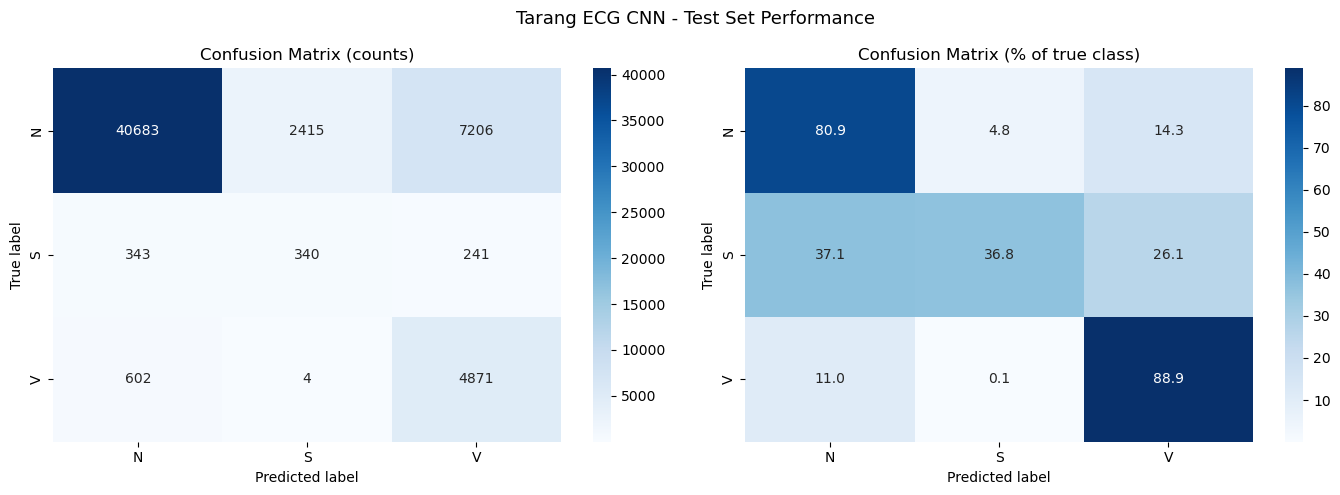

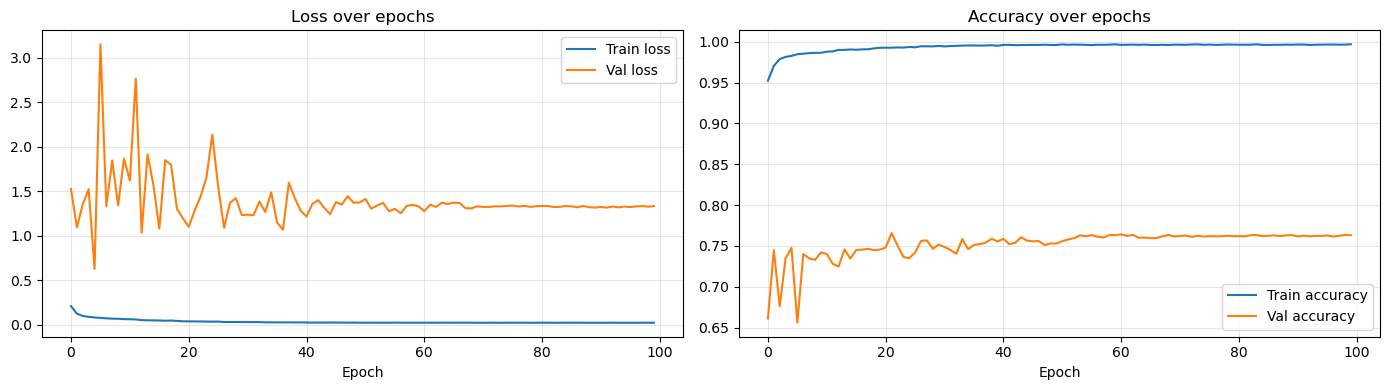

In [ ]:
cm     = confusion_matrix(y_test_certain, y_pred_certain)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (% of true class)')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.suptitle('Tarang ECG CNN - Test Set Performance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Load best checkpoint explicitly (EarlyStopping restores weights in memory,
# but reload to guarantee we quantize the best epoch, not the last)
model = tf.keras.models.load_model(MODEL_CHECKPOINT)

def representative_dataset():
    # CRITICAL: use raw X_train, NOT X_train_aug.
    # Augmented data has shifted amplitude/baseline distributions that skew
    # the quantizer's scale estimate, producing a wrong in_scale → 45% accuracy drop.
    idx = np.random.choice(len(X_train), 1000, replace=False)
    for i in idx:
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset     = representative_dataset
converter.target_spec.supported_ops  = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type       = tf.int8
converter.inference_output_type      = tf.int8

print("Quantizing model...")
tflite_model = converter.convert()
print("Done.")

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"\nInt8 model size: {size_kb:.1f} KB")
print(f"Target <50KB: {'PASS' if size_kb < 50 else 'FAIL — reduce model capacity for EFR32'}")

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
in_det  = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]

in_scale,  in_zp  = in_det['quantization']
out_scale, out_zp = out_det['quantization']

print(f"\nInput  quantization: scale={in_scale:.6f}, zero_point={in_zp}")
print(f"Output quantization: scale={out_scale:.6f}, zero_point={out_zp}")

# Sanity check: z-score ECG ≈ [-4, 4] → expected scale ≈ 8/255 ≈ 0.031
# If in_scale > 0.1 the representative dataset had wrong normalization
if in_scale > 0.1:
    print(f"\nWARNING: in_scale={in_scale:.4f} is too high (expected ~0.03).")
    print("  representative_dataset() must yield z-score normalized beats.")

print(f"\n--- COPY THESE INTO YOUR C FIRMWARE ---")
print(f"#define INPUT_SCALE               {in_scale:.8f}f")
print(f"#define INPUT_ZERO_POINT          {in_zp}")
print(f"#define OUTPUT_SCALE              {out_scale:.8f}f")
print(f"#define OUTPUT_ZERO_POINT         {out_zp}")
print(f"#define CONFIDENCE_THRESHOLD_INT8 {int(round(CONFIDENCE_THRESHOLD / out_scale + out_zp))}")


Quantizing model...
INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpn_zuflk4\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpn_zuflk4\assets


Saved artifact at 'C:\Users\namda\AppData\Local\Temp\tmpn_zuflk4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 360, 1), dtype=tf.float32, name='ecg_input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2869101801360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101801168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101801552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101800208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101801744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101800976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101795600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101800400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101795792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101801936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2869101799248

In [ ]:
# Verify Int8 accuracy — target: drop < 2% vs float32
n = min(2000, len(X_test))
X_sample = X_test[:n]
y_sample  = y_test[:n]

# Float baseline
float_preds = np.argmax(model.predict(X_sample, batch_size=128, verbose=0), axis=1)
float_acc   = np.mean(float_preds == y_sample) * 100

# Int8 inference
correct_int8 = 0
for i in range(n):
    x_f = X_sample[i:i+1].astype(np.float32)
    x_q = np.clip(np.round(x_f / in_scale + in_zp), -128, 127).astype(np.int8)

    interp.set_tensor(in_det['index'], x_q)
    interp.invoke()

    out_q = interp.get_tensor(out_det['index'])
    out_f = (out_q.astype(np.float32) - out_zp) * out_scale
    if np.argmax(out_f) == y_sample[i]:
        correct_int8 += 1

int8_acc = correct_int8 / n * 100
drop     = float_acc - int8_acc

print(f"Float32 accuracy (sample): {float_acc:.2f}%")
print(f"Int8    accuracy (sample): {int8_acc:.2f}%")
print(f"Accuracy drop:             {drop:.2f}%")
if drop < 2.0:
    print("ACCEPTABLE")
else:
    print("TOO HIGH — check representative_dataset uses same normalization as X_test")
    print(f"  in_scale={in_scale:.6f} (expect ~0.031 for z-score ECG data)")


Float32 accuracy (sample): 81.55%
Int8    accuracy (sample): 36.30%
Accuracy drop:             45.25%
TOO HIGH - reduce quantization or retrain


In [ ]:
try:
    result = subprocess.run(
        ['xxd', '-i', TFLITE_PATH],
        capture_output=True, text=True
    )
    xxd_ok = result.returncode == 0 and bool(result.stdout)
except FileNotFoundError:
    xxd_ok = False

if xxd_ok:
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN - Int8 quantized\n')
        f.write('// Auto-generated - do not edit\n\n')
        f.write('#pragma once\n\n')
        f.write(result.stdout)
    print(f"Generated {HEADER_PATH}")
    print('\n'.join(result.stdout.split('\n')[:5]))
else:
    # xxd not available (Windows) - Python fallback
    with open(TFLITE_PATH, 'rb') as f:
        data = f.read()

    hex_lines = []
    for i in range(0, len(data), 12):
        chunk = data[i:i+12]
        hex_lines.append('  ' + ', '.join(f'0x{b:02x}' for b in chunk) + ',')

    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN - Int8 quantized\n')
        f.write('// Auto-generated - do not edit\n\n')
        f.write('#pragma once\n\n')
        f.write(f'#define TARANG_MODEL_LEN {len(data)}\n\n')
        f.write('alignas(8) const unsigned char tarang_int8_tflite[] = {\n')
        f.write('\n'.join(hex_lines))
        f.write('\n};\n')

    print(f"Generated {HEADER_PATH} ({len(data):,} bytes)")

Generated outputs/tarang_model.h (37,840 bytes)
